### Regresion y Clasificacion

Regresion lineal

Regresion no Lineal:
-Regresion polinomica
-Regresion con Kernels
-Redes Neuronales 
-Modelos basados en arboles

Multicolinealidad
Se busca que la variable objetivo este altamente correlacionada con las variables predictoras
pero ENTRE las variables predictoras la alta correlacio produce multicolinealidad lo que dificilta el modelo y estabilidad



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
datos=pd.read_csv("Sueldos.csv")
datos

,ingreso,trabaja,horas,ninos16,ninos18,edad,educ,ciudad,exp,ninosp
0,3.3540,1,1610,1,0,32,12,0,14,Si
1,1.3889,1,1656,0,2,30,12,1,5,No
2,4.5455,1,1980,1,3,35,12,0,15,Si
3,1.0965,1,456,0,3,34,12,0,6,No
4,4.5918,1,1568,1,2,31,14,1,7,Si
...,...,...,...,...,...,...,...,...,...,...
748,0.0000,0,0,0,2,40,13,1,5,No
749,0.0000,0,0,2,3,31,12,0,14,Si
750,0.0000,0,0,0,0,43,12,0,4,No
751,0.0000,0,0,0,0,60,12,1,15,No


In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ingreso  753 non-null    float64
 1   trabaja  753 non-null    int64  
 2   horas    753 non-null    int64  
 3   ninos16  753 non-null    int64  
 4   ninos18  753 non-null    int64  
 5   edad     753 non-null    int64  
 6   educ     753 non-null    int64  
 7   ciudad   753 non-null    int64  
 8   exp      753 non-null    int64  
 9   ninosp   753 non-null    object 
dtypes: float64(1), int64(8), object(1)
memory usage: 59.0+ KB


In [4]:
df=datos[datos['trabaja']==1]
df

,ingreso,trabaja,horas,ninos16,ninos18,edad,educ,ciudad,exp,ninosp
0,3.3540,1,1610,1,0,32,12,0,14,Si
1,1.3889,1,1656,0,2,30,12,1,5,No
2,4.5455,1,1980,1,3,35,12,0,15,Si
3,1.0965,1,456,0,3,34,12,0,6,No
4,4.5918,1,1568,1,2,31,14,1,7,Si
...,...,...,...,...,...,...,...,...,...,...
423,2.3118,1,680,0,5,36,10,0,2,No
424,5.3061,1,2450,0,1,40,12,1,21,No
425,5.8675,1,2144,0,2,43,13,1,22,No
426,3.4091,1,1760,0,1,33,12,1,14,No


In [5]:
df['ingreso_corregido']=df['ingreso']*10000
df

C:\Users\l\AppData\Local\Temp\ipykernel_11028\3490532487.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ingreso_corregido']=df['ingreso']*10000


,ingreso,trabaja,horas,ninos16,ninos18,edad,educ,ciudad,exp,ninosp,ingreso_corregido
0,3.3540,1,1610,1,0,32,12,0,14,Si,33540.0
1,1.3889,1,1656,0,2,30,12,1,5,No,13889.0
2,4.5455,1,1980,1,3,35,12,0,15,Si,45455.0
3,1.0965,1,456,0,3,34,12,0,6,No,10965.0
4,4.5918,1,1568,1,2,31,14,1,7,Si,45918.0
...,...,...,...,...,...,...,...,...,...,...,...
423,2.3118,1,680,0,5,36,10,0,2,No,23118.0
424,5.3061,1,2450,0,1,40,12,1,21,No,53061.0
425,5.8675,1,2144,0,2,43,13,1,22,No,58675.0
426,3.4091,1,1760,0,1,33,12,1,14,No,34091.0


In [11]:
df['ciudad'].value_counts()

ciudad
1    274
0    154
Name: count, dtype: int64

In [12]:
df['ninosp'] = df['ninosp'].map({'Si': True, 'No': False})
df

C:\Users\l\AppData\Local\Temp\ipykernel_11028\3545836517.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ninosp'] = df['ninosp'].map({'Si': True, 'No': False})


,ingreso,trabaja,horas,ninos16,ninos18,edad,educ,ciudad,exp,ninosp,ingreso_corregido
0,3.3540,1,1610,1,0,32,12,0,14,True,33540.0
1,1.3889,1,1656,0,2,30,12,1,5,False,13889.0
2,4.5455,1,1980,1,3,35,12,0,15,True,45455.0
3,1.0965,1,456,0,3,34,12,0,6,False,10965.0
4,4.5918,1,1568,1,2,31,14,1,7,True,45918.0
...,...,...,...,...,...,...,...,...,...,...,...
423,2.3118,1,680,0,5,36,10,0,2,False,23118.0
424,5.3061,1,2450,0,1,40,12,1,21,False,53061.0
425,5.8675,1,2144,0,2,43,13,1,22,False,58675.0
426,3.4091,1,1760,0,1,33,12,1,14,False,34091.0


In [15]:
df.columns[2]

'horas'

In [ ]:
df=df.iloc[:,2: ]#todas las filas, desde la columna 2 [0,1,2,3,4,5,6,7,8,9,10]->[2,3,4,5,6,7,8,9,10]
df

,horas,ninos16,ninos18,edad,educ,ciudad,exp,ninosp,ingreso_corregido
0,1610,1,0,32,12,0,14,True,33540.0
1,1656,0,2,30,12,1,5,False,13889.0
2,1980,1,3,35,12,0,15,True,45455.0
3,456,0,3,34,12,0,6,False,10965.0
4,1568,1,2,31,14,1,7,True,45918.0
...,...,...,...,...,...,...,...,...,...
423,680,0,5,36,10,0,2,False,23118.0
424,2450,0,1,40,12,1,21,False,53061.0
425,2144,0,2,43,13,1,22,False,58675.0
426,1760,0,1,33,12,1,14,False,34091.0


In [21]:
X=df.iloc[:,:7]
X

,horas,ninos16,ninos18,edad,educ,ciudad,exp
0,1610,1,0,32,12,0,14
1,1656,0,2,30,12,1,5
2,1980,1,3,35,12,0,15
3,456,0,3,34,12,0,6
4,1568,1,2,31,14,1,7
...,...,...,...,...,...,...,...
423,680,0,5,36,10,0,2
424,2450,0,1,40,12,1,21
425,2144,0,2,43,13,1,22
426,1760,0,1,33,12,1,14


In [20]:
y=df['ingreso_corregido']
y

0      33540.0
1      13889.0
2      45455.0
3      10965.0
4      45918.0
        ...   
423    23118.0
424    53061.0
425    58675.0
426    34091.0
427    40816.0
Name: ingreso_corregido, Length: 428, dtype: float64

In [27]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X=scaler.fit_transform(X)
print(X)

[[0.3236128  0.5        0.         ... 0.58333333 0.         0.36842105]
 [0.33292831 0.         0.25       ... 0.58333333 1.         0.13157895]
 [0.39854192 0.5        0.375      ... 0.58333333 0.         0.39473684]
 ...
 [0.43175375 0.         0.25       ... 0.66666667 1.         0.57894737]
 [0.35398947 0.         0.125      ... 0.58333333 1.         0.36842105]
 [0.09680032 0.         0.125      ... 0.58333333 1.         0.18421053]]


In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
from sklearn.linear_model import LinearRegression
model_lr=LinearRegression()
model_lr.fit(X_train,y_train)

LinearRegression()

In [36]:
predicciones=model_lr.predict(X_test)

In [32]:
print('Rendimiento data train: ', model_lr.score(X_train,y_train))
print('Rendimiento data test: ', model_lr.score(X_test,y_test))

Rendimiento data train:  0.16484548458933312
Rendimiento data test:  0.0017533163879889235


In [33]:
comparacion=pd.DataFrame(y_test)
comparacion['prediccion']=model_lr.predict(X_test)    
comparacion

,ingreso_corregido,prediccion
420,25720.0,35954.950130
75,49819.0,36993.470961
177,15845.0,26873.884953
30,15385.0,43480.193573
362,27778.0,54223.395133
...,...,...
377,34091.0,60638.449735
57,80409.0,61699.448305
124,98611.0,64550.054094
24,21545.0,33278.343230


In [ ]:
df.iloc[420] #revisar la fila 420  original

horas                   1944
ninos16                    0
ninos18                    2
edad                      49
educ                      12
ciudad                     1
exp                       13
ninosp                 False
ingreso_corregido    25720.0
Name: 420, dtype: object

In [37]:
#metricas de evaluacion
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error

r2=r2_score(y_test,predicciones)
mae=mean_absolute_error(y_test,predicciones)
rmse=root_mean_squared_error(y_test,predicciones)
print(r2,mae,rmse)

0.0017533163879889235 22451.720094774355 33839.898293375845


In [39]:
from sklearn.ensemble import RandomForestRegressor
model_rf=RandomForestRegressor()
model_rf.fit(X_train,y_train)

RandomForestRegressor()

In [40]:
predicciones_rf=model_rf.predict(X_test)

In [41]:
r2=r2_score(y_test,predicciones_rf)
mae=mean_absolute_error(y_test,predicciones_rf)
rmse=root_mean_squared_error(y_test,predicciones_rf)
print(r2,mae,rmse)

-0.1919175810993019 22828.99430232558 36977.132028304106


Regresion Ridge:aborda porblemas de multicolinealidad en la regresion lineal,penaliza la funcion de costo basado en la suma de los cuadrados de los coeficientes, (solo puede reducir los coeficientes de variables, no hacerlos 0)
es util cuando: 
* hay multicolinealidad entre var independientes
* numero de variables es grande en relacion al numero de filas
* se busca evitar el sobreajuste

Regresion Lasso: ademas de reducir los coeficientes puede hacer cero algunos
es util cuando:
* se sospecha que solo algunas variables son realmente importante
* se quiere un modelo mas simple y facil de interpretar
* hay muchas variables y se busca seleccionar las mas relevantes
* se busca reducir el sobreajuste eliminando variables irrelevantes



Regresion ElasticNet: Combina Ridge y Lasso:
a=fuerza general de la regularizacion
p=balance entre las penalizaciones L1 y L2
cuando p=1: elasticnet se convierte en un lasso
cuando p=0: elasticnet se convierte en un ridge

util cuando:
* hay grupos de variables correlacionadas
* se busca un equilibrio entre seleccion de variables y reduccion de la varianza

In [42]:
from sklearn.linear_model import Lasso, Ridge,ElasticNet
model_ls=Lasso()
model_ls.fit(X_train,y_train)
model_rd=Ridge()
model_rd.fit(X_train,y_train)
model_en=ElasticNet()
model_en.fit(X_train,y_train)


ElasticNet()

In [43]:
predicciones_ls=model_ls.predict(X_test)
predicciones_rd=model_rd.predict(X_test)
predicciones_en=model_en.predict(X_test)

In [44]:
r2=r2_score(y_test,predicciones_ls)
mae=mean_absolute_error(y_test,predicciones_ls)
rmse=root_mean_squared_error(y_test,predicciones_ls)
print(r2,mae,rmse)
print('-------------------------------------------------------------------------------------')
r2=r2_score(y_test,predicciones_rd)
mae=mean_absolute_error(y_test,predicciones_rd)
rmse=root_mean_squared_error(y_test,predicciones_rd)
print(r2,mae,rmse)
print('-------------------------------------------------------------------------------------')
r2=r2_score(y_test,predicciones_en)
mae=mean_absolute_error(y_test,predicciones_en)
rmse=root_mean_squared_error(y_test,predicciones_en)
print(r2,mae,rmse)
print('-------------------------------------------------------------------------------------')

0.0019100024521025993 22449.370704833625 33837.242412500615
-------------------------------------------------------------------------------------
0.018975746020718498 22188.386634121634 33546.7137850578
-------------------------------------------------------------------------------------
0.019111276410567757 22068.18537809398 33544.396433463175
-------------------------------------------------------------------------------------


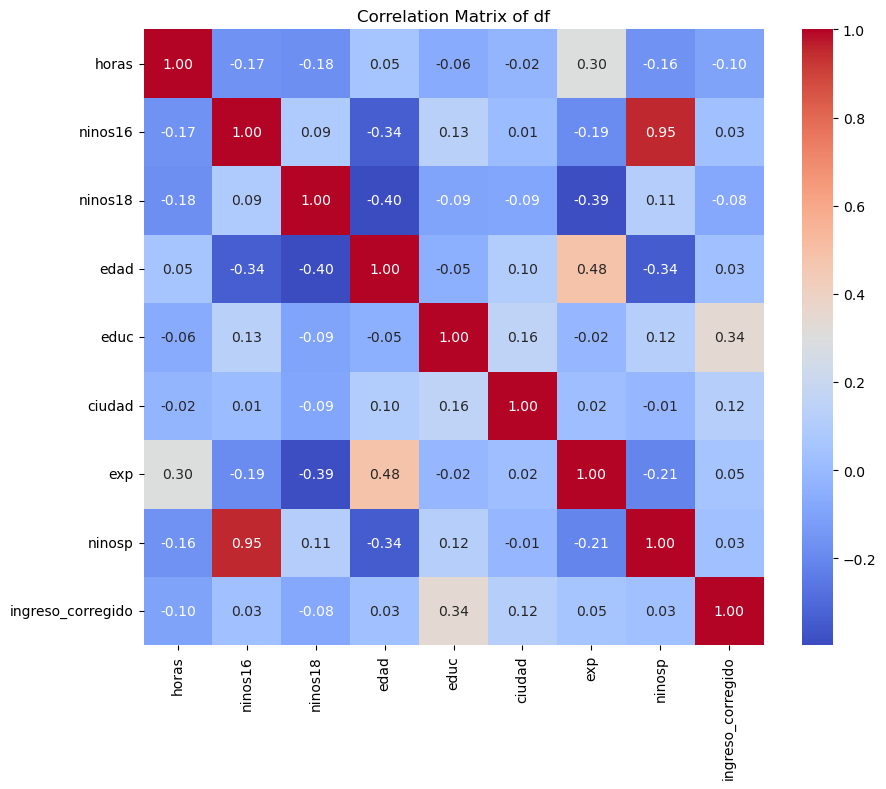

In [45]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt=".2f")
plt.title('Correlation Matrix of df')
plt.show()

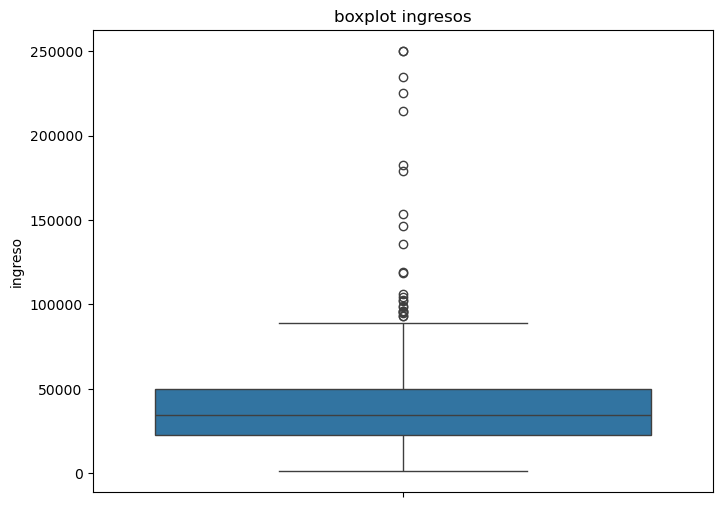

In [46]:
plt.figure(figsize=(8,6))
sns.boxplot(y=df['ingreso_corregido'])
plt.title('boxplot ingresos')
plt.ylabel('ingreso')
plt.show()

In [ ]:
#se observa que hay muchos outliers. hay que eliminar esos para mejorar los modelos

### Regresion con arbol de decision

### Regresion con random forest -> varios arboles de decision pero en paralelo

### Gradient Boosting -> varios arboles de decision pero secuenciales

### Support Vector Regression (SVR)-> con bordes de decision o hiperplanos para separar datos

### Redes neuronales para regresion

### Regresion para series temporales